In [1]:
import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from datetime import datetime, timedelta, date

# Locate premier_league/ regardless of where Jupyter was launched
_here = Path.cwd()
if not (_here / 'outputs.ipynb').exists():
    for _c in [_here / 'premier_league',
               _here / 'non_penalty_bayes' / 'premier_league',
               _here / 'team_strength' / 'non_penalty_bayes' / 'premier_league']:
        if _c.exists():
            os.chdir(_c)
            break

NOTEBOOK_DIR = Path.cwd().resolve()
NP_BAYES_DIR = str(NOTEBOOK_DIR.parent)
sys.path.insert(0, NP_BAYES_DIR)

REPO_ROOT = str(NOTEBOOK_DIR.parents[4])
sys.path.insert(0, os.path.join(REPO_ROOT, 'viz'))

from src.data_utils import load_and_process_data, load_football_data, create_weighted_scoreline_data, prepare_model_data
from src.model import build_and_sample_model
from src.simulation import (run_multiple_seasons, load_actual_results,
                             get_actual_standings, form_net_rating,
                             get_last_result, get_form_string, rank_arrow)
from pl_combined_table import render_combined_table
from pl_html_export import render_html_export
from pl_evo_chart import render_evo_chart
from pl_scatter import render_scatter
from logos import TEAM_LOGOS as team_logos

LEAGUE  = 'Premier_League'
SEASON  = '2025-2026'

DB_PATH = os.path.join(REPO_ROOT, 'infra', 'data', 'db', 'fotmob.db')

# Sampling
N_SAMPLES           = 20000
N_TUNE              = 10000
N_SAMPLES_EVOLUTION = 2000
N_TUNE_EVOLUTION    = 1000

# Blend weights
DECAY_RATE   = 0.0018
GOALS_WEIGHT = 0.25
XG_WEIGHT    = 0.50
PSXG_WEIGHT  = 0.15
EPV_WEIGHT   = 0.10

# Form weights
FORM_DECAY_RATE   = 0.0165 #0.025
FORM_GOALS_WEIGHT = 0.50
FORM_XG_WEIGHT    = 0.35
FORM_PSXG_WEIGHT  = 0.10
FORM_EPV_WEIGHT   = 0.05

BASELINE_HOME_PENS = 0.157 * 0.78
BASELINE_AWAY_PENS = 0.101 * 0.78

# ── Form window config ────────────────────────────────────────────────────────
FORM_END   = str(date.today())
FORM_START = (datetime.strptime(FORM_END, '%Y-%m-%d') - timedelta(weeks=12)).strftime('%Y-%m-%d')

# Derive FORM_PREV_END from the second-to-last custom gameweek.
# custom_gw uses calendar-window rules (Fri-Mon = weekend, Tue-Thu = midweek)
# with lone rescheduled fixtures merged into the preceding window — so this
# correctly handles international breaks, midweek rounds, and postponements.
import sqlite3 as _sqlite3
_conn = _sqlite3.connect(DB_PATH)
_gw_ends = pd.read_sql(
    """
    SELECT custom_gw, MAX(match_date) AS gw_end
    FROM matches
    WHERE league_id = ? AND season = ? AND home_goals IS NOT NULL
      AND custom_gw IS NOT NULL
    GROUP BY custom_gw
    ORDER BY custom_gw
    """,
    _conn, params=[LEAGUE, SEASON]
)['gw_end'].tolist()
_conn.close()

FORM_PREV_END = _gw_ends[-2] if len(_gw_ends) >= 2 else FORM_START

print(f'CWD:          {NOTEBOOK_DIR}')
print(f'DB:           {DB_PATH}')
print(f'FORM_END:     {FORM_END}')
print(f'FORM_PREV_END:{FORM_PREV_END}  (end of GW{len(_gw_ends) - 1} of {len(_gw_ends)})')


CWD:          /Users/admin/dev/algobetting/algo/models/team_strength/non_penalty_bayes/premier_league
DB:           /Users/admin/dev/algobetting/infra/data/db/fotmob.db
FORM_END:     2026-04-24
FORM_PREV_END:2026-04-20  (end of GW34 of 35)


## Current ratings — full season

In [2]:
df, team_mapping, n_teams = load_and_process_data(
    db_path=DB_PATH, league=LEAGUE, season=SEASON,
    decay_rate=DECAY_RATE, 
    goals_weight=GOALS_WEIGHT,
    xg_weight=XG_WEIGHT, 
    psxg_weight=PSXG_WEIGHT, 
    epv_weight=EPV_WEIGHT,

    gc_goals_weight=0,
    gc_xg_weight=0,
    gc_psxg_weight=0,
    gc_epv_weight=0,
)
team_names = list(team_mapping.keys())
print(f'{n_teams} teams, {df["match_id"].nunique()} matches')

20 teams, 332 matches


In [3]:
from manual_priors import MANUAL_ATT_PRIORS, MANUAL_DEF_PRIORS

_, trace = build_and_sample_model(
    df, n_teams, trace=N_SAMPLES, tune=N_TUNE,
    team_mapping=team_mapping,
    manual_att_priors=MANUAL_ATT_PRIORS,
    manual_def_priors=MANUAL_DEF_PRIORS,
)
print('Done.')

Done.


In [4]:
posterior = trace.posterior
att  = posterior['att_str'].values.reshape(-1, n_teams)
defn = posterior['def_str'].values.reshape(-1, n_teams)
hadv = posterior['home_adv'].values.reshape(-1)
base = posterior['baseline'].values.reshape(-1)

ratings = pd.DataFrame({
    'team':     team_names,
    'att_mean': att.mean(axis=0).round(3),
    'att_sd':   att.std(axis=0).round(3),
    'att_lo':   np.percentile(att, 5,  axis=0).round(3),
    'att_hi':   np.percentile(att, 95, axis=0).round(3),
    'def_mean': defn.mean(axis=0).round(3),
    'def_sd':   defn.std(axis=0).round(3),
    'def_lo':   np.percentile(defn, 5,  axis=0).round(3),
    'def_hi':   np.percentile(defn, 95, axis=0).round(3),
})
ratings['net'] = (ratings['att_mean'] - ratings['def_mean']).round(3)
ratings = ratings.sort_values('net', ascending=False).reset_index(drop=True)
ratings

,team,att_mean,att_sd,att_lo,att_hi,def_mean,def_sd,def_lo,def_hi,net
0,Arsenal,0.241,0.141,0.009,0.474,-0.462,0.187,-0.777,-0.164,0.703
1,Man City,0.321,0.142,0.078,0.547,-0.192,0.166,-0.472,0.076,0.513
2,Liverpool,0.243,0.141,0.002,0.471,-0.116,0.167,-0.396,0.156,0.359
3,Brighton,0.071,0.148,-0.176,0.313,-0.111,0.160,-0.382,0.148,0.182
4,Chelsea,0.194,0.146,-0.061,0.427,0.018,0.152,-0.238,0.263,0.176
5,Man United,0.148,0.147,-0.103,0.380,-0.022,0.156,-0.285,0.230,0.170
6,Brentford,0.058,0.155,-0.202,0.308,-0.053,0.162,-0.318,0.204,0.111
7,Bournemouth,0.137,0.147,-0.105,0.374,0.075,0.153,-0.176,0.321,0.062
8,Newcastle,0.064,0.147,-0.179,0.302,0.018,0.156,-0.240,0.270,0.046
9,Aston Villa,0.075,0.156,-0.185,0.324,0.041,0.153,-0.213,0.287,0.034


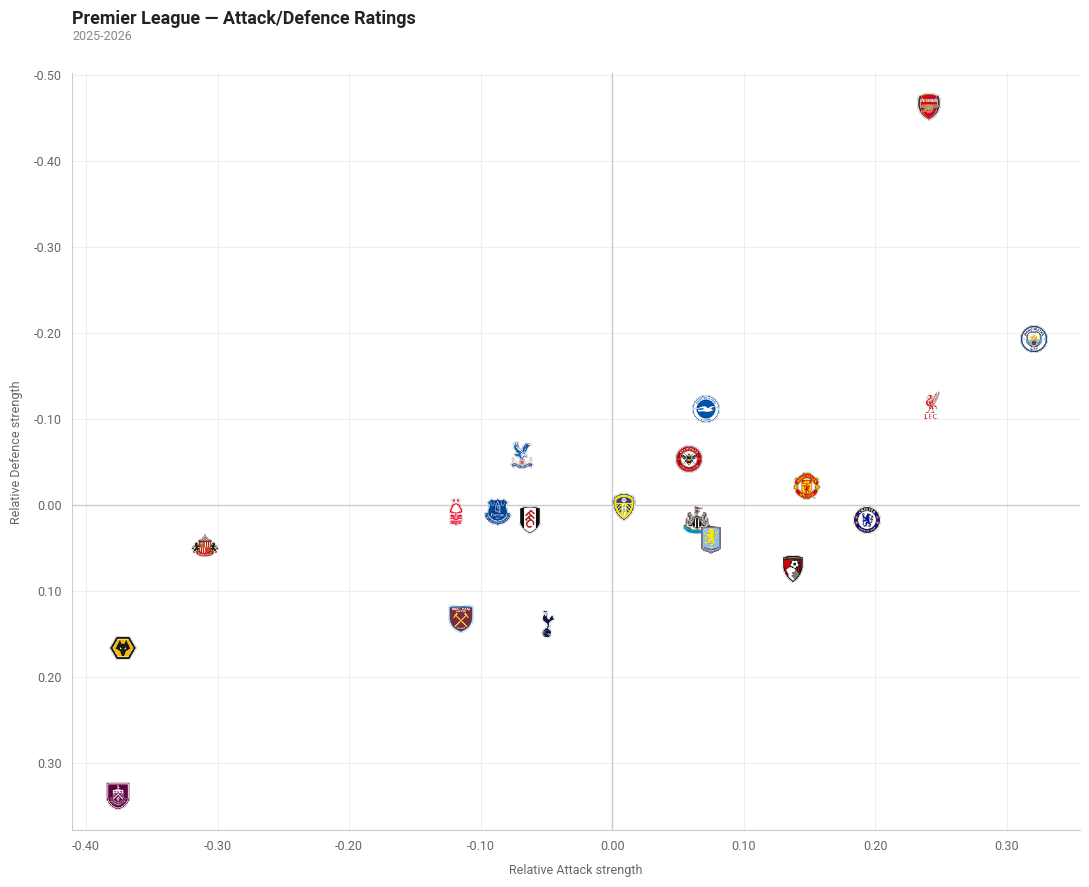

In [5]:
fig = render_scatter(ratings, season=SEASON, league='Premier League',
    save_path=os.path.join(str(NOTEBOOK_DIR), 'outputs', 'rating_scatter.png'))
plt.show()

## Season Projections

In [6]:
# ── ratings_df: Bayesian avg-vs-all-opponents (Jensen's corrected) ────────────
baseline_samples  = trace.posterior["baseline"].values.flatten()
home_adv_samples  = trace.posterior["home_adv"].values.flatten()
att_samples_all   = trace.posterior["att_str"].values.reshape(-1, n_teams)
def_samples_all   = trace.posterior["def_str"].values.reshape(-1, n_teams)
all_teams_list    = list(team_mapping.keys())

team_stats = {t: {"goals_for": 0, "goals_against": 0, "matches": 0} for t in all_teams_list}

for home_team in all_teams_list:
    hi = team_mapping[home_team]
    for away_team in all_teams_list:
        if home_team == away_team:
            continue
        ai = team_mapping[away_team]
        home_lam = np.exp(baseline_samples + home_adv_samples
                          + att_samples_all[:, hi] + def_samples_all[:, ai])
        away_lam = np.exp(baseline_samples + att_samples_all[:, ai] + def_samples_all[:, hi])

        hg = home_lam.mean() + BASELINE_HOME_PENS
        ag = away_lam.mean() + BASELINE_AWAY_PENS

        team_stats[home_team]["goals_for"]     += hg
        team_stats[home_team]["goals_against"] += ag
        team_stats[home_team]["matches"]       += 1
        team_stats[away_team]["goals_for"]     += ag
        team_stats[away_team]["goals_against"] += hg
        team_stats[away_team]["matches"]       += 1

ratings_df = pd.DataFrame([{
    "team":          t,
    "goals_for":     team_stats[t]["goals_for"]     / team_stats[t]["matches"],
    "goals_against": team_stats[t]["goals_against"] / team_stats[t]["matches"],
    "goal_diff":     (team_stats[t]["goals_for"] - team_stats[t]["goals_against"]) / team_stats[t]["matches"],
    "total_xg":      (team_stats[t]["goals_for"] + team_stats[t]["goals_against"]) / team_stats[t]["matches"],
} for t in all_teams_list]).sort_values("goal_diff", ascending=False).reset_index(drop=True)

print(ratings_df.to_string(index=False))

print('Totals')
print(f'Home goals: {ratings_df['goals_for'].sum():.2f}')
print(f'Away goals: {ratings_df['goals_against'].sum():.2f}')

          team  goals_for  goals_against  goal_diff  total_xg
       Arsenal   1.706105       0.880984   0.825121  2.587089
      Man City   1.821321       1.112866   0.708455  2.934187
     Liverpool   1.686747       1.199385   0.487362  2.886132
       Chelsea   1.602696       1.357172   0.245524  2.959867
    Man United   1.537932       1.312802   0.225130  2.850734
      Brighton   1.438402       1.215162   0.223240  2.653564
     Brentford   1.418475       1.282464   0.136011  2.700939
   Bournemouth   1.515520       1.435428   0.080092  2.950947
     Newcastle   1.420236       1.368180   0.052056  2.788416
   Aston Villa   1.433880       1.395179   0.038700  2.829059
         Leeds   1.352042       1.352529  -0.000487  2.704571
Crystal Palace   1.262187       1.284763  -0.022577  2.546950
        Fulham   1.265330       1.376412  -0.111082  2.641743
       Everton   1.238296       1.366577  -0.128280  2.604873
  Nottm Forest   1.202583       1.368250  -0.165667  2.570832
     Tot

In [7]:
# ── Load actual results + run 10k simulations (fresh-posterior) ───────────────
# Each simulation draws a fresh posterior sample for xG, propagating rating
# uncertainty through to final standings rather than using fixed posterior means.

from src.simulation import _update_table

df_actual = load_actual_results(DB_PATH, LEAGUE, SEASON)
print(f'Actual matches: {len(df_actual)}')

_played_df  = df_actual[df_actual['home_goals'].notna()].copy()
_played_set = {(r['home_team'], r['away_team']) for _, r in _played_df.iterrows()}
_actual_res = [
    (r['home_team'], r['away_team'], int(r['home_goals']), int(r['away_goals']))
    for _, r in _played_df.iterrows()
]

teams     = list(team_mapping.keys())
n_t       = len(teams)
_remaining = [(h, a) for h in teams for a in teams
               if h != a and (h, a) not in _played_set]
print(f"Remaining fixtures to simulate: {len(_remaining)}")

# Pre-extract posterior arrays once (outside the loop)
_att  = trace.posterior['att_str'].values.reshape(-1, n_t)
_def  = trace.posterior['def_str'].values.reshape(-1, n_t)
_base = trace.posterior['baseline'].values.flatten()
_hadv = trace.posterior['home_adv'].values.flatten()
_nd   = len(_base)

_hri = np.array([team_mapping[h] for h, a in _remaining])
_ari = np.array([team_mapping[a] for h, a in _remaining])

_acc = {k: np.zeros(n_t) for k in ['pts','pts_sq','w','d','l','gf','ga','xgf','xga','pos']}
_cnt = {k: np.zeros(n_t, dtype=np.int32) for k in ['title','top5','top8','rel']}
_pos_freq = np.zeros((n_t, n_t), dtype=np.int32)

N_SIMS = 10_000
print(f"Running {N_SIMS:,} simulations...")
for _s in range(N_SIMS):
    if _s % 2000 == 0 and _s > 0:
        print(f"  {_s:,} / {N_SIMS:,}")

    _tbl = {t: {'played':0,'w':0,'d':0,'l':0,'gf':0,'ga':0,'xgf':0.,'xga':0.,'pts':0}
            for t in teams}

    for _ht, _at, _hg, _ag in _actual_res:
        _update_table(_tbl, _ht, _at, _hg, _ag, 0., 0.)

    _i   = np.random.randint(_nd)
    _hxg = np.exp(_base[_i] + _hadv[_i] + _att[_i, _hri] + _def[_i, _ari]) + BASELINE_HOME_PENS
    _axg = np.exp(_base[_i] + _att[_i, _ari] + _def[_i, _hri]) + BASELINE_AWAY_PENS
    _hgs = np.random.poisson(_hxg)
    _ags = np.random.poisson(_axg)
    for _j, (_ht, _at) in enumerate(_remaining):
        _update_table(_tbl, _ht, _at, int(_hgs[_j]), int(_ags[_j]),
                      float(_hxg[_j]), float(_axg[_j]))

    _pts = np.array([_tbl[t]['pts'] for t in teams])
    _gd  = np.array([_tbl[t]['gf'] - _tbl[t]['ga'] for t in teams])
    _gf  = np.array([_tbl[t]['gf'] for t in teams])
    _ord = np.lexsort((_gf, _gd, _pts))[::-1]
    _pos = np.empty(n_t, dtype=np.int32)
    _pos[_ord] = np.arange(1, n_t + 1)

    _acc['pts']    += _pts
    _acc['pts_sq'] += _pts ** 2
    _acc['w']      += [_tbl[t]['w']   for t in teams]
    _acc['d']      += [_tbl[t]['d']   for t in teams]
    _acc['l']      += [_tbl[t]['l']   for t in teams]
    _acc['gf']     += [_tbl[t]['gf']  for t in teams]
    _acc['ga']     += [_tbl[t]['ga']  for t in teams]
    _acc['xgf']    += [_tbl[t]['xgf'] for t in teams]
    _acc['xga']    += [_tbl[t]['xga'] for t in teams]
    _acc['pos']    += _pos
    _cnt['title']  += (_pos == 1)
    _cnt['top5']   += (_pos <= 5)
    _cnt['top8']   += (_pos <= 8)
    _cnt['rel']    += (_pos >= 18)
    _pos_freq[np.arange(n_t), _pos - 1] += 1

_N   = N_SIMS
_std = np.sqrt(np.maximum(_acc['pts_sq'] / _N - (_acc['pts'] / _N) ** 2, 0))

avg_table = pd.DataFrame({
    'team':              teams,
    'avg_points':        _acc['pts']  / _N,
    'pts_low':           _acc['pts']  / _N - 1.28 * _std,
    'pts_high':          _acc['pts']  / _N + 1.28 * _std,
    'avg_wins':          _acc['w']    / _N,
    'avg_draws':         _acc['d']    / _N,
    'avg_losses':        _acc['l']    / _N,
    'avg_goals_for':     _acc['gf']   / _N,
    'avg_goals_against': _acc['ga']   / _N,
    'avg_xg_for':        _acc['xgf']  / _N,
    'avg_xg_against':    _acc['xga']  / _N,
    'avg_position':      _acc['pos']  / _N,
    'title_pct':         np.round(_cnt['title'] / _N * 100, 1),
    'top5_pct':          np.round(_cnt['top5']  / _N * 100, 1),
    'top8_pct':          np.round(_cnt['top8']  / _N * 100, 1),
    'relegation_pct':    np.round(_cnt['rel']   / _N * 100, 1),
})
avg_table['avg_goal_difference'] = avg_table['avg_goals_for']  - avg_table['avg_goals_against']
avg_table['avg_xg_difference']   = avg_table['avg_xg_for']     - avg_table['avg_xg_against']
avg_table = avg_table.sort_values(
    ['avg_points', 'avg_goal_difference', 'avg_goals_for'], ascending=False
).reset_index(drop=True)
avg_table.index += 1

position_freq = {t: list(_pos_freq[i]) for i, t in enumerate(teams)}
avg_table

Actual matches: 332
Remaining fixtures to simulate: 48
Running 10,000 simulations...
  2,000 / 10,000
  4,000 / 10,000
  6,000 / 10,000
  8,000 / 10,000


,team,avg_points,pts_low,pts_high,avg_wins,avg_draws,avg_losses,avg_goals_for,avg_goals_against,avg_xg_for,avg_xg_against,avg_position,title_pct,top5_pct,top8_pct,relegation_pct,avg_goal_difference,avg_xg_difference
1,Arsenal,80.2846,76.748832,83.820368,24.0593,8.1067,5.8340,72.3244,29.9791,9.318981,3.947162,1.3938,60.6,100.0,100.0,0.0,42.3453,5.371820
2,Man City,79.1179,75.269163,82.966637,23.6594,8.1397,6.2009,75.0345,34.6021,9.072737,5.597984,1.6071,39.4,100.0,100.0,0.0,40.4324,3.474753
3,Man United,65.5488,61.645615,69.451985,18.1007,11.2467,8.6526,65.4229,51.4330,7.438803,6.403197,3.7666,0.0,97.2,100.0,0.0,13.9899,1.035606
4,Aston Villa,64.9478,61.178928,68.716672,18.9248,8.1734,10.9018,54.2925,48.2830,7.328888,7.287514,4.0436,0.0,97.0,100.0,0.0,6.0095,0.041374
5,Liverpool,63.1535,59.276022,67.030978,18.3235,8.1830,11.4935,62.3183,49.3404,8.320029,6.352639,4.4201,0.0,90.0,99.7,0.0,12.9779,1.967390
6,Brighton,56.3640,52.998280,59.729720,14.7904,11.9928,11.2168,53.9848,43.6658,5.914551,4.725062,7.2669,0.0,7.6,78.5,0.0,10.3190,1.189488
7,Brentford,54.5443,50.785753,58.302847,14.7754,10.2181,13.0065,54.6730,51.2338,6.639735,7.240339,8.7294,0.0,3.4,49.2,0.0,3.4392,-0.600605
8,Bournemouth,54.4878,51.051089,57.924511,12.5083,16.9629,8.5288,57.7403,57.7952,5.702668,5.811117,8.9656,0.0,1.1,44.8,0.0,-0.0549,-0.108449
9,Chelsea,54.4020,50.996191,57.807809,14.8271,9.9207,13.2522,59.5109,50.2205,6.526246,5.224030,8.5504,0.0,2.2,53.7,0.0,9.2904,1.302216
10,Everton,53.5235,49.722428,57.324572,14.7426,9.2957,13.9617,46.1205,45.6124,6.115838,6.631311,9.6494,0.0,1.0,33.5,0.0,0.5081,-0.515474


/Users/admin/dev/algobetting/viz/pl_combined_table.py:297: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0)


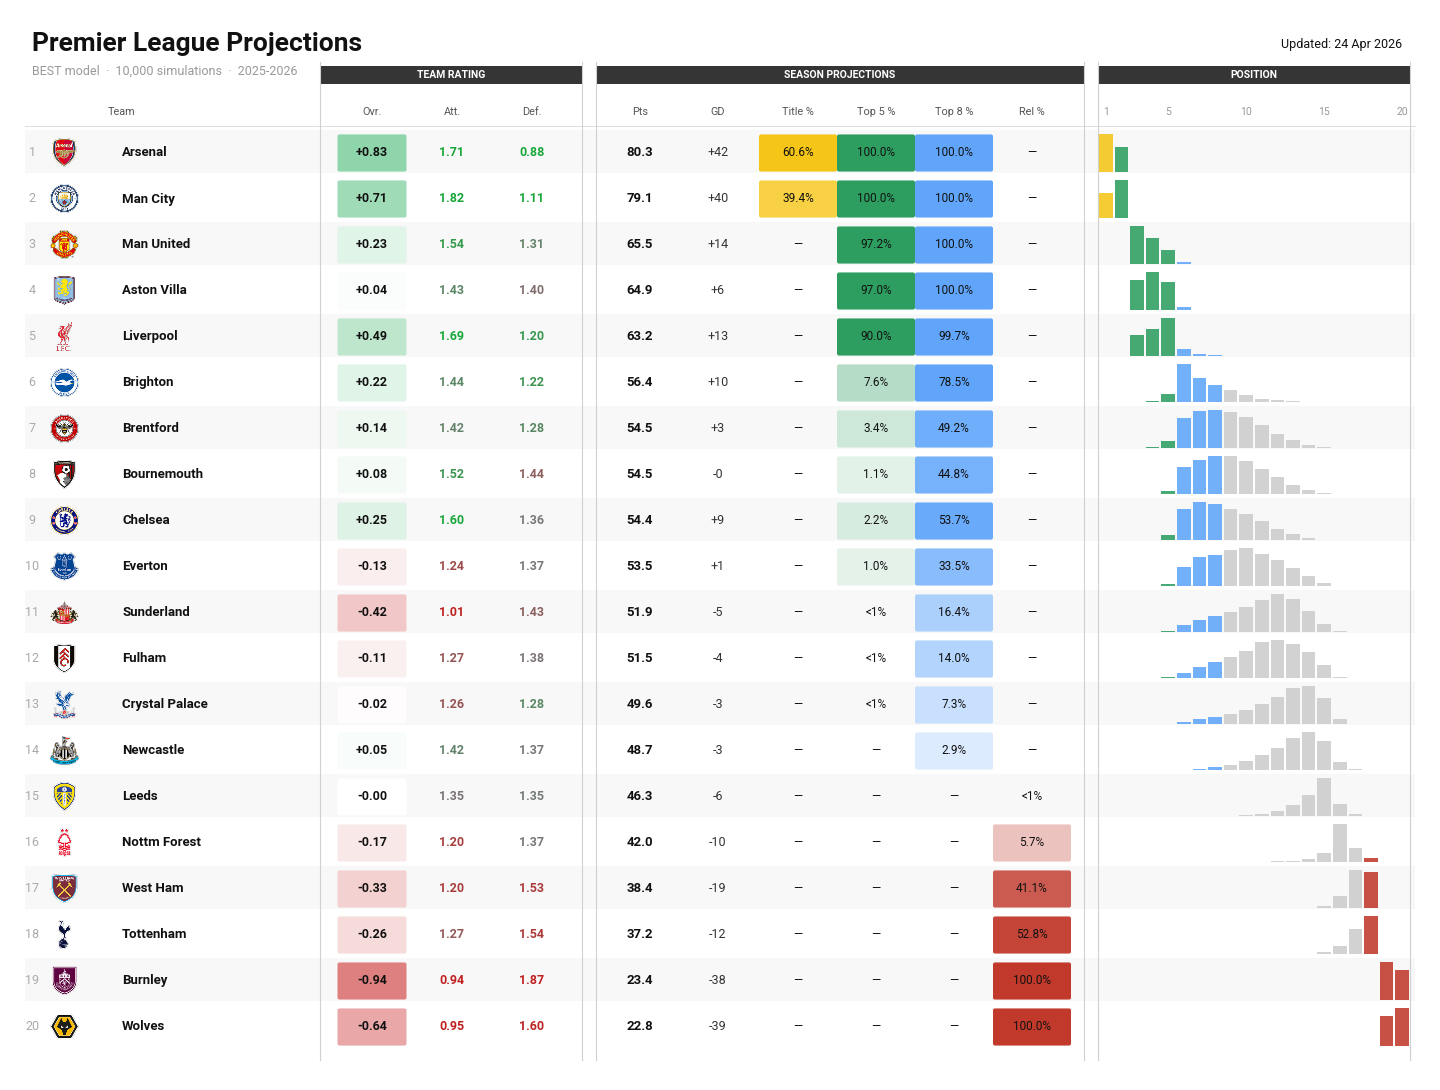

In [8]:
# ── 538-style combined table ──────────────────────────────────────────────────
fig = render_combined_table(
    avg_table     = avg_table,
    position_freq = position_freq,
    ratings_df    = ratings_df,
    n_sims        = N_SIMS,
    season        = SEASON,
    team_logos    = team_logos,
)
plt.savefig(os.path.join(str(NOTEBOOK_DIR), 'outputs', 'best_table.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## Next GW Fixture Predictions

In [9]:
# ── Fetch all remaining PL fixtures from TheSportsDB ─────────────────────────
import requests
import time
from scipy.stats import poisson
from datetime import date as _date_cls

_SPORTSDB_TO_MODEL = {
    'Arsenal': 'Arsenal',
    'Aston Villa': 'Aston Villa',
    'Bournemouth': 'Bournemouth',
    'Brentford': 'Brentford',
    'Brighton and Hove Albion': 'Brighton',
    'Burnley': 'Burnley',
    'Chelsea': 'Chelsea',
    'Crystal Palace': 'Crystal Palace',
    'Everton': 'Everton',
    'Fulham': 'Fulham',
    'Leeds United': 'Leeds',
    'Liverpool': 'Liverpool',
    'Manchester City': 'Man City',
    'Manchester United': 'Man United',
    'Newcastle United': 'Newcastle',
    'Nottingham Forest': 'Nottm Forest',
    'Sunderland': 'Sunderland',
    'Tottenham Hotspur': 'Tottenham',
    'West Ham United': 'West Ham',
    'Wolverhampton Wanderers': 'Wolves',
}

def _get_all_remaining_fixtures(start_round=1):
    """Fetch every unplayed PL fixture from start_round to end of season."""
    fixtures = []
    for rnd in range(start_round, 39):
        try:
            r = requests.get(
                f'https://www.thesportsdb.com/api/v1/json/3/eventsround.php?id=4328&r={rnd}&s=2025-2026',
                timeout=10,
            )
            events = r.json().get('events') or []
            time.sleep(1)
        except Exception:
            continue
        for e in events:
            if e.get('intHomeScore') is None:
                fixtures.append({
                    'date': e['dateEvent'],
                    'time': (e.get('strTime') or '')[:5],
                    'gw':   e['intRound'],
                    'home': _SPORTSDB_TO_MODEL.get(e['strHomeTeam'], e['strHomeTeam']),
                    'away': _SPORTSDB_TO_MODEL.get(e['strAwayTeam'], e['strAwayTeam']),
                })
    return sorted(fixtures, key=lambda x: (x['date'], x['time']))

# ── Draw posterior samples once ───────────────────────────────────────────────
posterior = trace.posterior
_att  = posterior['att_str'].values.reshape(-1, n_teams)
_defn = posterior['def_str'].values.reshape(-1, n_teams)
_hadv = posterior['home_adv'].values.reshape(-1)
_base = posterior['baseline'].values.reshape(-1)
_rng  = np.random.choice(len(_base), size=2000, replace=True)

def _predict(home_team, away_team):
    """Return (home_lam, away_lam) including penalty baseline."""
    hi = team_mapping[home_team]
    ai = team_mapping[away_team]
    home_lam = np.mean(np.exp(
        _base[_rng] + _hadv[_rng] + _att[_rng, hi] + _defn[_rng, ai]
    )) + BASELINE_HOME_PENS
    away_lam = np.mean(np.exp(
        _base[_rng] + _att[_rng, ai] + _defn[_rng, hi]
    )) + BASELINE_AWAY_PENS
    return home_lam, away_lam

def _match_probs(home_lam, away_lam, max_goals=10):
    """Win / Draw / Loss probabilities via Poisson convolution."""
    h = np.array([poisson.pmf(g, home_lam) for g in range(max_goals + 1)])
    a = np.array([poisson.pmf(g, away_lam) for g in range(max_goals + 1)])
    grid = np.outer(h, a)
    win  = float(np.tril(grid, -1).sum())
    draw = float(np.trace(grid))
    loss = float(np.triu(grid,  1).sum())
    return win, draw, loss

# ── Build predictions for all remaining fixtures ──────────────────────────────
_today_str = str(_date_cls.today())
# Start from the last official PL round in the DB (not custom_gw count)
import sqlite3 as _sq
_conn_r = _sq.connect(DB_PATH)
_max_round = _conn_r.execute(
    "SELECT MAX(CAST(round AS INTEGER)) FROM matches "
    "WHERE league_id=? AND season=? AND home_goals IS NOT NULL",
    [LEAGUE, SEASON]
).fetchone()[0] or 1
_conn_r.close()
_start_round = max(1, _max_round)
print(f"Fetching from official round {_start_round} onwards")
fixtures   = _get_all_remaining_fixtures(start_round=_start_round)
print(f"Fetched {len(fixtures)} remaining fixtures")

rows = []
for f in fixtures:
    if f['home'] not in team_mapping or f['away'] not in team_mapping:
        print(f"Warning: unknown team(s) — {f['home']} / {f['away']}")
        continue
    hl, al = _predict(f['home'], f['away'])
    w, d, l = _match_probs(hl, al)
    rows.append({
        'GW':      f['gw'],
        'Date':    f['date'],
        'Time':    f['time'],
        'Home':    f['home'],
        'Away':    f['away'],
        'Home xG': round(hl, 2),
        'Away xG': round(al, 2),
        'Home W%': round(w * 100, 1),
        'Draw%':   round(d * 100, 1),
        'Away W%': round(l * 100, 1),
    })

_PRED_COLS = ['GW','Date','Time','Home','Away','Home xG','Away xG','Home W%','Draw%','Away W%']
pred_df = pd.DataFrame(rows, columns=_PRED_COLS) if rows else pd.DataFrame(columns=_PRED_COLS)
if pred_df.empty:
    print("Warning: no upcoming fixtures fetched — check TheSportsDB API.")
# Show only next GW fixtures
_next_gw = pred_df["GW"].min()
next_gw_df = pred_df[pred_df["GW"] == _next_gw].reset_index(drop=True)
next_gw_df

Fetching from official round 34 onwards
Fetched 47 remaining fixtures


,GW,Date,Time,Home,Away,Home xG,Away xG,Home W%,Draw%,Away W%
0,34,2026-04-24,19:00,Sunderland,Nottm Forest,1.10,1.14,34.7,28.8,36.6
1,34,2026-04-25,11:30,Fulham,Aston Villa,1.41,1.32,39.3,25.7,35.0
2,34,2026-04-25,14:00,Liverpool,Crystal Palace,1.70,1.03,53.2,24.0,22.8
3,34,2026-04-25,14:00,West Ham,Everton,1.31,1.26,37.9,26.5,35.6
4,34,2026-04-25,14:00,Wolves,Tottenham,1.17,1.36,32.1,26.7,41.2
5,34,2026-04-25,16:30,Arsenal,Newcastle,1.83,0.85,60.7,22.4,16.9
6,34,2026-04-27,19:00,Man United,Brentford,1.57,1.26,44.5,24.8,30.7


Saved → /Users/admin/dev/algobetting/algo/models/team_strength/non_penalty_bayes/premier_league/outputs/gw_predictions.png


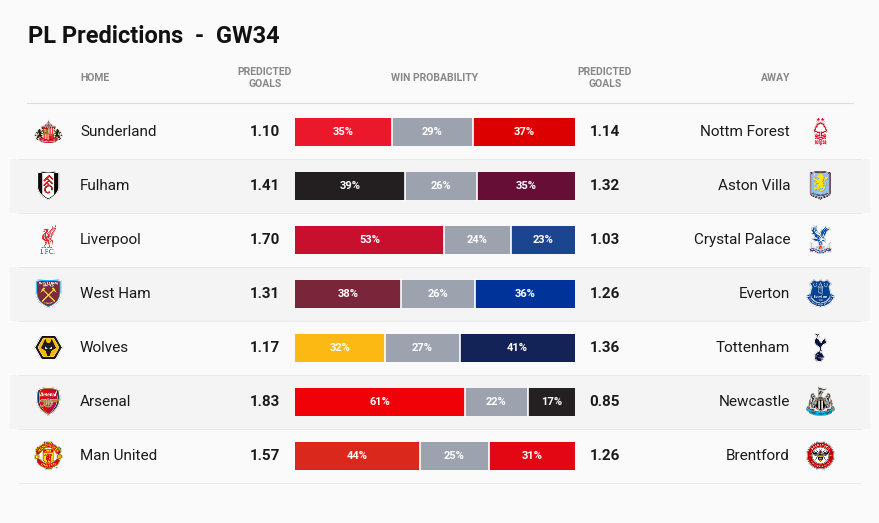

In [10]:
# ── GW predictions viz ───────────────────────────────────────────────────────
from pl_gw_predictions_viz import render_gw_predictions

fig = render_gw_predictions(
    gw_df      = next_gw_df,
    team_logos = team_logos,
    gw_label   = f"GW{_next_gw}",
    save_path  = os.path.join(str(NOTEBOOK_DIR), "outputs", "gw_predictions.png"),
)
plt.show()

In [11]:
# ── Asian handicap fair odds — next GW fixtures ───────────────────────────────
from src.asian_handicap import price_asian_handicap

rows = []
for _, fx in next_gw_df.iterrows():
    lines = price_asian_handicap(fx['Home xG'], fx['Away xG'])
    lo, mid, hi = lines[0], lines[1], lines[2]
    rows.append({
        'Home':         fx['Home'],
        'Away':         fx['Away'],
        'Lo Line':      lo['line'],
        'Lo H':         lo['home_odds'],
        'Lo A':         lo['away_odds'],
        'Fair Line':    mid['line'],
        'Fair H':       mid['home_odds'],
        'Fair A':       mid['away_odds'],
        'Hi Line':      hi['line'],
        'Hi H':         hi['home_odds'],
        'Hi A':         hi['away_odds'],
    })

ah_df = pd.DataFrame(rows)
ah_df

,Home,Away,Lo Line,Lo H,Lo A,Fair Line,Fair H,Fair A,Hi Line,Hi H,Hi A
0,Sunderland,Nottm Forest,-0.25,2.40,1.71,0.00,2.06,1.95,0.25,1.79,2.27
1,Fulham,Aston Villa,-0.25,2.17,1.85,0.00,1.89,2.12,0.25,1.70,2.43
2,Liverpool,Crystal Palace,-0.75,2.19,1.84,-0.50,1.88,2.13,-0.25,1.63,2.59
3,West Ham,Everton,-0.25,2.23,1.81,0.00,1.94,2.07,0.25,1.72,2.38
4,Wolves,Tottenham,0.00,2.28,1.78,0.25,1.95,2.06,0.50,1.70,2.43
5,Arsenal,Newcastle,-1.25,2.42,1.70,-1.00,2.12,1.90,-0.75,1.86,2.17
6,Man United,Brentford,-0.50,2.24,1.80,-0.25,1.93,2.08,0.00,1.69,2.45


In [18]:
from src.asian_handicap import price_asian_handicap, _goal_grid, _ah_probs

HOME_LAM = 1.70
AWAY_LAM = 1.03
LINE     = -1.25  # home perspective: negative = home favoured

ph, pa = _ah_probs(_goal_grid(HOME_LAM, AWAY_LAM), LINE)
print(f"AH {LINE:+.2f}   Home: {1/ph:.3f}   Away: {1/pa:.3f}")

AH -1.25   Home: 2.977   Away: 1.506


## Power rankings — short window + season simulation

In [12]:
# ── Power rankings — short window form ratings ───────────────────────────────
pr_df, pr_map, pr_n = load_and_process_data(
    db_path=DB_PATH, league=LEAGUE, season=SEASON, start=FORM_START,
    decay_rate=FORM_DECAY_RATE, goals_weight=FORM_GOALS_WEIGHT,
    xg_weight=FORM_XG_WEIGHT, psxg_weight=FORM_PSXG_WEIGHT, epv_weight=FORM_EPV_WEIGHT,
)
print(f'Window: {FORM_START} → latest  |  {pr_n} teams, {pr_df["match_id"].nunique()} matches')

pr_form = form_net_rating(pr_df)
pr_form['rank'] = range(1, len(pr_form) + 1)
pr_form

Window: 2026-01-30 → latest  |  20 teams, 102 matches


,gf_avg,ga_avg,net_rating,rank
home_team,,,,
Man City,2.018979,0.918501,1.100478,1
Brighton,1.643565,0.871190,0.772374,2
Liverpool,1.767921,1.175445,0.592477,3
Bournemouth,1.592027,1.085198,0.506829,4
Arsenal,1.607408,1.123912,0.483496,5
Nottm Forest,1.467357,1.142790,0.324567,6
West Ham,1.360235,1.152895,0.207340,7
Leeds,1.321384,1.123908,0.197476,8
Crystal Palace,0.999749,0.839040,0.160709,9


## HTML Power Rankings Export

Generates `substack_power_rankings.html`. Open in browser → Select All (Cmd+A) → Copy → Paste into Substack.

In [13]:
# ── Form ratings: current window vs previous week ─────────────────────────────
df_form_current, _, _ = load_and_process_data(
    db_path=DB_PATH, league=LEAGUE, season=SEASON, start=FORM_START,
    decay_rate=FORM_DECAY_RATE, goals_weight=FORM_GOALS_WEIGHT,
    xg_weight=FORM_XG_WEIGHT, psxg_weight=FORM_PSXG_WEIGHT, epv_weight=FORM_EPV_WEIGHT,
)
form_current = form_net_rating(df_form_current)
form_current['form_rank'] = range(1, len(form_current) + 1)

df_form_prev, _, _ = load_and_process_data(
    db_path=DB_PATH, league=LEAGUE, season=SEASON, start=FORM_START,
    end=datetime.strptime(FORM_PREV_END, '%Y-%m-%d').date(),
    decay_rate=FORM_DECAY_RATE, goals_weight=FORM_GOALS_WEIGHT,
    xg_weight=FORM_XG_WEIGHT, psxg_weight=FORM_PSXG_WEIGHT, epv_weight=FORM_EPV_WEIGHT,
)
form_prev = form_net_rating(df_form_prev)
form_prev['prev_form_rank'] = range(1, len(form_prev) + 1)

form_merged = form_current.merge(
    form_prev[['prev_form_rank']], left_index=True, right_index=True, how='left'
)


print(form_merged[['net_rating', 'form_rank', 'prev_form_rank']].head(10))

# ── Actual standings ──────────────────────────────────────────────────────────
played = df_actual[df_actual['home_goals'].notna()].copy()
_teams = list(team_mapping.keys())
pts_d = {t: 0 for t in _teams}
gf_d  = {t: 0 for t in _teams}
ga_d  = {t: 0 for t in _teams}
for _, r in played.iterrows():
    h, a = r['home_team'], r['away_team']
    if h not in pts_d or a not in pts_d:
        continue
    hg, ag = int(r['home_goals']), int(r['away_goals'])
    gf_d[h] += hg; ga_d[h] += ag
    gf_d[a] += ag; ga_d[a] += hg
    if   hg > ag: pts_d[h] += 3
    elif ag > hg: pts_d[a] += 3
    else:         pts_d[h] += 1; pts_d[a] += 1

standings = pd.DataFrame({
    'team': _teams,
    'pts':  [pts_d[t] for t in _teams],
    'gf':   [gf_d[t]  for t in _teams],
    'ga':   [ga_d[t]  for t in _teams],
    'gd':   [gf_d[t] - ga_d[t] for t in _teams],
}).sort_values(['pts', 'gd', 'gf'], ascending=False).reset_index(drop=True)
standings['table_pos'] = range(1, len(standings) + 1)

# ── Ratings ranks ─────────────────────────────────────────────────────────────
ratings_ranked = ratings_df.copy()
ratings_ranked['att_rank'] = ratings_ranked['goals_for'].rank(ascending=False).astype(int)
ratings_ranked['def_rank'] = ratings_ranked['goals_against'].rank(ascending=True).astype(int)
print(standings[['team', 'pts', 'gd', 'table_pos']].to_string(index=False))


                net_rating  form_rank  prev_form_rank
home_team                                            
Man City          1.100478          1               1
Brighton          0.772374          2               5
Liverpool         0.592477          3               2
Bournemouth       0.506829          4               3
Arsenal           0.483496          5               4
Nottm Forest      0.324567          6               7
West Ham          0.207340          7               8
Leeds             0.197476          8               6
Crystal Palace    0.160709          9               9
Man United        0.131747         10              10
          team  pts  gd  table_pos
      Man City   70  37          1
       Arsenal   70  37          2
    Man United   58  13          3
   Aston Villa   58   6          4
     Liverpool   55  11          5
      Brighton   50   9          6
   Bournemouth   49   0          7
       Chelsea   48   8          8
     Brentford   48   4          9
  

Saved → /Users/admin/dev/algobetting/algo/models/team_strength/non_penalty_bayes/premier_league/outputs/power_rankings.png


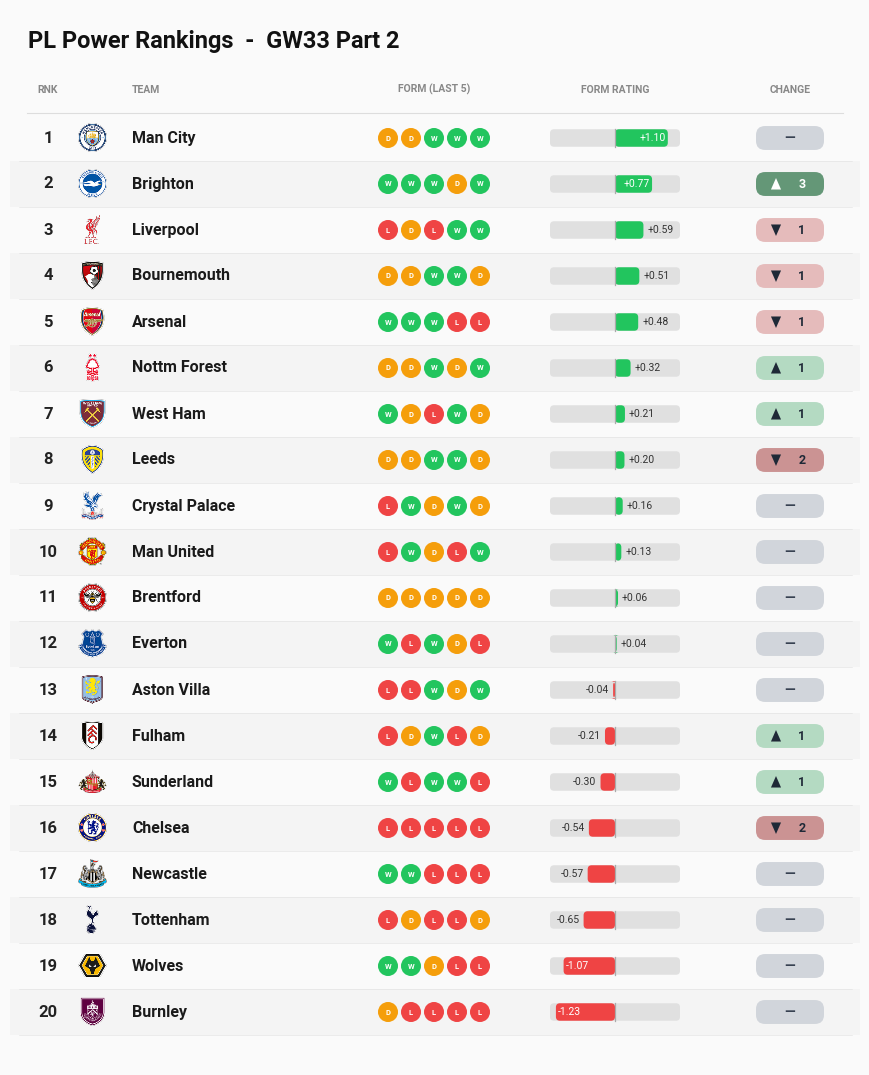

In [14]:
# ── matplotlib Power Rankings visualization ──────────────────────────────
from pl_power_rankings_viz import render_power_rankings

_gw_num   = len(_gw_ends)
_gw_label = f'GW{_gw_num}'

fig = render_power_rankings(
    form_merged     = form_merged,
    df_actual       = df_actual,
    team_logos      = team_logos,
    gw_label        = 'GW33 Part 2',
    form_end        = FORM_END,
    get_form_string = get_form_string,
    save_path       = os.path.join(str(NOTEBOOK_DIR), 'outputs', 'power_rankings.png'),
)
plt.show()


In [15]:
# ── Build next-fixture map: first fixture after today for every team ──────────
next_fixture_map = {}
_upcoming = pred_df[pred_df['Date'] > _today_str].copy()

for _, fx in _upcoming.iterrows():
    home_team = fx['Home']
    away_team = fx['Away']
    if home_team not in next_fixture_map:
        next_fixture_map[home_team] = {
            'home_team':  home_team,
            'away_team':  away_team,
            'home_xg':    fx['Home xG'],
            'away_xg':    fx['Away xG'],
            'home_away':  'H',
        }
    if away_team not in next_fixture_map:
        next_fixture_map[away_team] = {
            'home_team':  home_team,
            'away_team':  away_team,
            'home_xg':    fx['Home xG'],
            'away_xg':    fx['Away xG'],
            'home_away':  'A',
        }

missing = [t for t in form_merged.index if t not in next_fixture_map]
if missing:
    print(f"No upcoming fixture found for: {missing}")

# ── Generate Substack HTML ────────────────────────────────────────────────────
output_html = os.path.join(str(NOTEBOOK_DIR), 'outputs', 'substack_power_rankings.html')
render_html_export(
    form_merged      = form_merged,
    standings        = standings,
    ratings_ranked   = ratings_ranked,
    team_logos       = team_logos,
    df_actual        = df_actual,
    form_end         = FORM_END,
    output_path      = output_html,
    get_last_result  = get_last_result,
    get_form_string  = get_form_string,
    rank_arrow       = rank_arrow,
    next_fixture_map = next_fixture_map,
)


Saved to /Users/admin/dev/algobetting/algo/models/team_strength/non_penalty_bayes/premier_league/outputs/substack_power_rankings.html
Open in a browser → Select All (Cmd+A) → Copy (Cmd+C) → Paste into Substack.


'/Users/admin/dev/algobetting/algo/models/team_strength/non_penalty_bayes/premier_league/outputs/substack_power_rankings.html'

## Ratings evolution — GW5 onwards

Fits the model after each gameweek and tracks how team strengths change across the season.

**Runtime note:** at 20k/10k draws this loop takes a while (~15 min per GW).
Lower `N_SAMPLES_EVOLUTION` in the setup cell if you want it faster.

In [16]:
# Derive GW cutoff dates from custom_gw in the DB
import sqlite3 as _sqlite3
_conn = _sqlite3.connect(DB_PATH)
_gw_df = pd.read_sql(
    """
    SELECT custom_gw, MAX(match_date) AS gw_end
    FROM matches
    WHERE league_id = ? AND season = ? AND home_goals IS NOT NULL
      AND custom_gw IS NOT NULL
    GROUP BY custom_gw
    ORDER BY custom_gw
    """,
    _conn, params=[LEAGUE, SEASON]
)
_conn.close()

gw_cutoffs = [pd.to_datetime(d).date() for d in _gw_df["gw_end"]]

# played_evo still needed for team list in the evo loop
match_df_evo, *_ = load_football_data(DB_PATH, LEAGUE, SEASON)
played_evo = match_df_evo[match_df_evo["home_goals"].notna()].copy()
played_evo["match_date"] = pd.to_datetime(played_evo["match_date"])

print(f"{len(gw_cutoffs)} gameweeks detected")
print(f"GW1 end: {gw_cutoffs[0]}   GW5 end: {gw_cutoffs[4]}   Last GW: {gw_cutoffs[-1]}")


35 gameweeks detected
GW1 end: 2025-08-18   GW5 end: 2025-09-21   Last GW: 2026-04-22


In [17]:
run_evolution = False

if run_evolution:
    # Consistent team index across all GW iterations
    all_teams = sorted(set(played_evo['home_team'].unique()) | set(played_evo['away_team'].unique()))
    full_map  = {t: i for i, t in enumerate(all_teams)}
    n_all     = len(all_teams)

    from manual_priors import MANUAL_ATT_PRIORS, MANUAL_DEF_PRIORS

    def fit_gw(cutoff_date):
        """Fit the same model as the main run, on data up to cutoff_date."""
        gw_df, _, _ = load_and_process_data(
            db_path=DB_PATH, league=LEAGUE, season=SEASON,
            end=cutoff_date,
            decay_rate=DECAY_RATE, goals_weight=GOALS_WEIGHT,
            xg_weight=XG_WEIGHT, psxg_weight=PSXG_WEIGHT, epv_weight=EPV_WEIGHT,
        )
        # Override indices to use the full consistent team list
        gw_df = gw_df.copy()
        gw_df['home_idx'] = gw_df['home_team'].map(full_map).astype(int)
        gw_df['away_idx'] = gw_df['away_team'].map(full_map).astype(int)

        _, tr = build_and_sample_model(
            gw_df, n_all,
            trace=N_SAMPLES_EVOLUTION, tune=N_TUNE_EVOLUTION,
            team_mapping=full_map,
            manual_att_priors=MANUAL_ATT_PRIORS,
            manual_def_priors=MANUAL_DEF_PRIORS,
        )
        post = tr.posterior
        return (
            post['att_str'].values.reshape(-1, n_all).mean(axis=0),
            post['def_str'].values.reshape(-1, n_all).mean(axis=0),
        )

    # Run from GW5 onwards (index 4)
    evo_records = []
    for gw_num, cutoff in enumerate(gw_cutoffs[4:], start=5):
        print(f'GW{gw_num} ({cutoff})...', end=' ', flush=True)
        att_means, def_means = fit_gw(cutoff)
        for i, team in enumerate(all_teams):
            evo_records.append({
                'gw':      gw_num,
                'date':    cutoff,
                'team':    team,
                'att':     att_means[i],
                'def':     def_means[i],
                'net':     att_means[i] - def_means[i],
            })
        print('done')

    evo_df = pd.DataFrame(evo_records)
    print(f'Evolution data: {len(evo_df)} rows')


    for metric in ['net', 'att', 'def']:
        fig = render_evo_chart(evo_df, metric=metric, season=SEASON, league='Premier League',
            save_path=os.path.join(str(NOTEBOOK_DIR), 'outputs', f'evo_{metric}.png'))
        plt.show()